# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [48]:
# importar librerías

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Configuración visual básica
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [50]:
# cargar archivos csv
df_plans = pd.read_csv('/datasets/plans.csv')
df_users = pd.read_csv('/datasets/users_latam.csv')
df_usage = pd.read_csv('/datasets/usage.csv')

In [51]:
# mostrar las primeras 5 filas de plans
df_plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.20,0.08,0.10
1,Premium,500,20,600,25,1.00,0.05,0.07


In [52]:
# mostrar las primeras 5 filas de users
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [53]:
# mostrar las primeras 5 filas de usage
df_usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.00
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.00
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [54]:
# revisar el número de filas y columnas de cada dataset
print(df_plans.shape)
print(df_users.shape)
print(df_usage.shape)

(2, 8)
(4000, 8)
(40000, 6)


In [55]:
# inspección de plans con .info()
print(df_plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes
None


In [56]:
# inspección de users con .info()
print(df_users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB
None


In [57]:
# inspección de usage con .info()
print(df_usage.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB
None


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [58]:
# cantidad de nulos para users
print(df_users.isna().sum())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [59]:
# cantidad de nulos para usage
print(df_usage.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
     * La columna 'usage' tiene valores faltantes, en la fila 'date' es del 0.125%, 'duration' del 55% y 'length' del 45%.
     * La columna 'users' tiene valores faltantes en la fila city del 11% y en churn date del 88%.
- Indica qué harías: ¿imputar, eliminar, ignorar?
     * En el caso de la columna 'usage', dejaría como nulos los valores faltantes de la fila date, e investigaría los datos de las filas duration y length.
     * En cuanto a la columna 'users', investigaría los datos de las filas city y churn date

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [60]:
# explorar columnas numéricas de users
df_users.describe()

,user_id,age
count,"4,000.00","4,000.00"
mean,"11,999.50",33.74
std,"1,154.84",123.23
min,"10,000.00",-999.00
25%,"10,999.75",32.00
50%,"11,999.50",47.00
75%,"12,999.25",63.00
max,"13,999.00",79.00


- La columna `user_id`tiene 4.000 en la columna `count`, lo que coincide con el número de usuarios y no evidencia valores nulos.  El valor de 'min' es 10.000 y el de 'max' es 13.999; los identificadores son consecutivos y son coherentes.  Su promedio (mean) y desviación estándar (std), aunque Pandas los calcula, no tienen utilidad analítica, porque el promedio o la desviación estándar de un identificador no aporta información del negocio. Un 'user_id' simplemente identifica a cada usuario.
- La columna `age` no tiene valores nulos en la fila `count`. Nos muestra que la edad promedio es de 33.74 años, es decir, alrededor de 34 años; sin embargo, este valor no es representativo, ya que está siendo afectado por un valor extremadamente bajo que no alcanza a ser "detectado" pues se muestra como -999, número que nos indica que es un dato faltante o desconocido (sentinel). La edad máxima es de 79, la mediana es de 47.  El 25% de las personas de este data frame tiene 32 años, mientras el 75% tiene 63 años.  El 50% central de los usuarios tiene edades entre los 32 y 63 años, un rango coherente.  La desviación estándar es 123.23, una cifra anormalmente alta para una variable como la edad. Esto confirma que el valor -999 está distorsionando las estadísticas descriptivas.
  

In [61]:
# explorar columnas numéricas de usage
df_usage.describe()

,id,user_id,duration,length
count,"40,000.00","40,000.00","17,924.00","22,104.00"
mean,"20,000.50","12,002.41",5.20,52.13
std,"11,547.15","1,157.28",6.84,56.61
min,1.00,"10,000.00",0.00,0.00
25%,"10,000.75","10,996.00",1.44,37.00
50%,"20,000.50","12,013.00",3.50,50.00
75%,"30,000.25","13,005.00",6.99,64.00
max,"40,000.00","13,999.00",120.00,"1,490.00"


In [62]:
# explorar columnas categóricas de users
df_users[['city','plan']].head()
df_users['plan'].value_counts(dropna=False)
df_users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [63]:
* La columna `city` muestra diferencias en la forma en que se escriben los nombres de las ciudades, pues algunas están como abreviaturas en mayúsculas sostenidas y otras en estilo de título; por lo tanto, deben estandardizarse. 
* Hay una ciudad identificada con un signo de interrogación; esto puede considerarse un sentinel o un valor inválido utilizado para representar una ciudad desconocida o faltante.
* En la columna `plan` no se identifican problemas de calidad aparentes en esta variable. Los valores observados (Básico y Premium) son consistentes y no se evidencian categorías inesperadas o inválidas.

SyntaxError: invalid syntax (1584833004.py, line 1)

In [ ]:
# explorar columna categórica de usage
df_usage['type'].unique() # completa el código

- La columna `type` presenta únicamente dos categorías válidas (call y text), sin valores inválidos o inconsistentes.


In [ ]:
df_usage['type'].head()

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y qué acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  * Del dataframe users, la columna 'city' tiene varios sentinels.
- ¿Qué acción tomarías?
  * Se recomienda tomar acciones de 'investigar para imputar'.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
df_usage['date'] = pd.to_datetime(df_usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
df_users['reg_date'].dt.year.value_counts().sort_index()

En `reg_date` se identifican registros correspondientes a los años 2022, 2023 y 2024, que son coherentes con el período de análisis. Sin embargo, también aparecen 40 registros del año 2026, un año posterior al límite establecido (2024). Estos registros representan fechas fuera de rango y probablemente corresponden a errores de captura o de carga de datos.

In [ ]:
# Revisar los años presentes en `date` de usage
df_usage['date'].dt.year.value_counts().sort_index()

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

* En `date`, todos los registros válidos corresponden al año 2024, por lo que las fechas se encuentran dentro del rango esperado. 
* No se identifican años futuros ni fechas imposibles. 
* No es necesario realizar correcciones sobre la columna date, ya que las fechas son consistentes con el período de análisis.
* Basaremos el análisis en estas fechas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age

#Calculamos la mediana de age
age_mediana = df_users.loc[df_users['age'] != -999, 'age'].median()

# Luego reemplazamos el sentinel
df_users['age'] = df_users['age'].replace(-999, age_mediana)

# Verificamos los cambios
df_users['age'].describe()


In [ ]:
# Reemplazar el sentinel`"?"` por valores nulos (`pd.NA`)
df_users['city'] = df_users['city'].replace('?', pd.NA)

# Verificar cambios
df_users['city'].describe()

In [ ]:
# Convertir churn_date y reg_date a fecha y hora
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'], errors='coerce')
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'], errors='coerce')

# Marca como nulas (`pd.NA`) las fechas fuera de rango
df_users.loc[
    df_users['churn_date'].dt.year > 2024,
    'churn_date'
] = pd.NaT

# Verificar cambios
df_users['churn_date'].describe()

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration

pd.crosstab(
    df_usage['type'],
    df_usage['duration'].isna(),
    colnames=['Duration es nulo']
)

In [ ]:
df_usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# Verificación MAR en usage (Missing At Random) para length

pd.crosstab(
    df_usage['type'],
    df_usage['length'].isna(),
    colnames=['Length es nulo']
)

In [ ]:
df_usage[(df_usage['type'] == 'text') & (df_usage['duration'].notna())]

In [ ]:
df_usage[(df_usage['type'] == 'call') & (df_usage['length'].notna())]

Haz doble clic aquí y escribe que tu diagnóstico de nulos en `duration` y `length`
* La mayoría de los valores nulos en duration y length dependen del tipo de evento (type); pueden conservarse.
* No obstante, se identificaron 16 registros de tipo text con duration = 120.00 y 12 registros de tipo call con length = 1,490.00
* Dado que todos presentan exactamente el mismo valor, es probable que correspondan a valores por defecto o errores de captura.
* Aunque representan una proporción muy pequeña del conjunto de datos (0,07 %), se recomienda validarlos con la fuente de información antes de utilizarlos en un análisis y catalogarlos como una red flag.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
df_usage["is_text"] = (df_usage["type"] == "text").astype(int) #conocer el total de mensajes
df_usage["is_call"] = (df_usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
df_usage_agg = (
    df_usage.groupby("user_id")
    .agg(
        cant_mensajes=("is_text", "sum"),
        cant_llamadas=("is_call", "sum"),
        cant_minutos_llamada=("duration", "sum")
    )
    .reset_index()
)

# observar resultado
df_usage_agg.head(3)

In [ ]:
# Renombrar columnas

# observar resultado
df_usage_agg.head(3)

In [ ]:
# Combinar la tabla agregada con el dataset de usuarios

df_user_profile = df_users.merge(
    df_usage_agg,
    on='user_id',
    how='left'
)

df_user_profile.head(5)


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
df_user_profile[
    ['age',
     'cant_mensajes',
     'cant_llamadas',
     'cant_minutos_llamada']
].describe()

In [ ]:
# Distribución porcentual del tipo de plan
df_user_profile['plan'].value_counts(normalize=True) * 100

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=df_user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de la edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: Ambos planes cuentan con usuarios distribuidos en prácticamente todos los rangos de edad. El plan Básico presenta una mayor variabilidad en las frecuencias por grupo de edad, mientras que el plan Premium muestra una distribución ligeramente más uniforme. No se observa un patrón claro que indique que un plan concentra usuarios de una edad específica.
- Distribución: Aproximadamente uniforme, con ligeras variaciones entre rangos de edad.

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=df_user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:  El plan Básico muestra más valores altos al compararlos con los del plan Premium.
- Distribución: ligero sesgo hacia la derecha.

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=df_user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: Los valores que vemos en el plan Básico, son más altos comparados con los valores del plan Premium.
- Distribución: ligero sesgo hacia la derecha.

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=df_user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Minutos de llamadas por plan')
plt.xlabel('Minutos de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: En ambos planes, la mayor concentración está entre los 10 y 30 minutos. A medida que aumentan los minutos, la frecuencia disminuye.

-Distribución: Sesgada hacia la derecha (asimetría positiva).

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>
- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [ ]:
# Visualizando usando BoxPlot 
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    plt.figure(figsize=(6,2))
    sns.boxplot(data=df_user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
- age: (presenta o no outliers) No presenta outliers relevantes. La edad se encuentra dentro de un rango esperado (18-79 años).
- cant_mensajes: Presenta algunos outliers superiores correspondientes a usuarios que envían una cantidad inusualmente alta de mensajes.
- cant_llamadas: Presenta algunos outliers superiores asociados con usuarios que realizan muchas llamadas.
- cant_minutos_llamada: Presenta outliers superiores más evidentes, correspondientes a usuarios con un consumo elevado de minutos.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:

    Q1 = df_user_profile[col].quantile(0.25)
    Q3 = df_user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f'{col}')
    print(f'Límite superior: {limite_superior:.2f}')
    print(f'Máximo observado: {df_user_profile[col].max()}')
    print('---------------------------')


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
df_user_profile[columnas_limites].describe()


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Mantener los outliers, ya que representan usuarios con un mayor uso del servicio de mensajería y no existen indicios de errores de captura.
- cant_llamadas: mantener o no outliers, porqué? Mantener los outliers, porque reflejan usuarios con un mayor número de llamadas y no corresponden a valores imposibles.
- cant_minutos_llamada: mantener o no outliers, porqué? Mantener los outliers, ya que representan usuarios de alto consumo y no hay evidencia de errores de captura. Eliminarlos podría sesgar el análisis del comportamiento real de los clientes.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
import numpy as np

# Crear columna grupo_uso
condiciones = [
    (df_user_profile['cant_llamadas'] < 5) & (df_user_profile['cant_mensajes'] < 5),
    (df_user_profile['cant_llamadas'] < 10) & (df_user_profile['cant_mensajes'] < 10)
]

valores = [
    'Bajo uso',
    'Uso medio'
]

df_user_profile['grupo_uso'] = np.select(
    condiciones,
    valores,
    default='Alto uso'
)

# Verificar resultado
df_user_profile[['cant_mensajes', 'cant_llamadas', 'grupo_uso']].head(10)

In [ ]:
# verificar cambios
df_user_profile.head()

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [64]:
# Crear columna grupo_edad
condiciones = [
    (df_user_profile['age'] < 30),
    (df_user_profile['age'] < 60)
]
valores = [
    'Joven',
    'Adulto'
]
df_user_profile['grupo_edad'] = np.select(
    condiciones,
    valores,
    default='Adulto Mayor'
)

# Verificar resultado
df_user_profile[['age', 'grupo_edad']].head(10)


,age,grupo_edad
0,38.00,Adulto
1,53.00,Adulto
2,57.00,Adulto
3,69.00,Adulto Mayor
4,63.00,Adulto Mayor
5,61.00,Adulto Mayor
6,39.00,Adulto
7,70.00,Adulto Mayor
8,76.00,Adulto Mayor
9,47.00,Adulto


In [65]:
# verificar cambios
df_user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.00,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.00,3.00,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.00,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.00,10.00,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.00,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.00,2.00,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.00,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.00,3.00,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.00,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.00,3.00,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

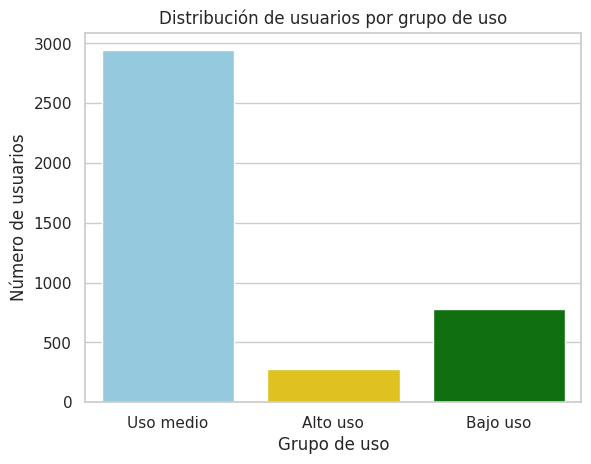

In [66]:

# Visualización de los segmentos por uso
sns.countplot(
    data=df_user_profile,
    x='grupo_uso',
    palette=['skyblue', 'gold', 'green']
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Número de usuarios')
plt.show()


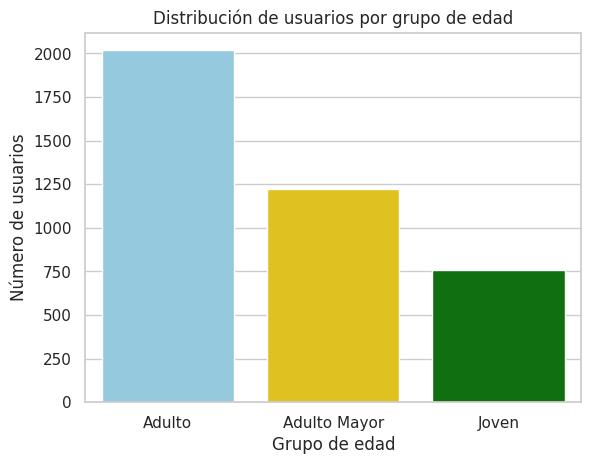

In [67]:
# Visualización de los segmentos por edad

sns.countplot(
    data=df_user_profile,
    x='grupo_edad',
    palette=['skyblue', 'gold', 'green']
)


plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Número de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmente los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
  *Durante la fase de exploración se identificaron varios problemas de calidad de datos: - La columna **age** contenía valores sentinel (-999), que representaban edades inválidas. Estos registros fueron reemplazados por la mediana de la columna para conservar la información del usuario. - La columna **city** contenía el valor **"?"** como indicador de ciudad desconocida. Estos valores fueron reemplazados por `pd.NA` para representar correctamente los datos faltantes. - La columna **reg_date** presentaba **40 registros con fechas del año 2026**, equivalentes al **1 % de los 4.000 usuarios**, aunque el análisis corresponde a datos hasta 2024. Estas fechas fueron marcadas como nulas.
  *En el dataset **usage**, las columnas **duration** y **length** presentaban valores nulos que dependían del tipo de evento (`call` o `text`), se concluyó que correspondían a datos **Missing At Random (MAR)** y, por consiguiente, se conservaron sin imputación, ya que representan el comportamiento normal de la base de datos y no errores de captura.
  
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
  *Se identificaron dos tipos de segmentación: **Segmentación por edad** - Joven (< 30 años) - Adulto (30 a 59 años) - Adulto Mayor (60 años o más) **Segmentación por nivel de uso** - Bajo uso - Uso medio - Alto uso
  *El análisis mostró que la mayor parte de los clientes se concentra en el segmento de **uso medio**, mientras que un grupo reducido corresponde a usuarios de **alto uso**, caracterizados por realizar un mayor número de llamadas, enviar más mensajes y acumular más minutos de conversación. Respecto a la edad, los usuarios se encuentran distribuidos entre los tres grupos sin evidenciar una relación clara entre la edad y el plan contratado.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
  *Los clientes de **alto uso** representan el segmento de mayor valor para ConnectaTel, ya que son quienes utilizan con mayor intensidad los servicios de llamadas y mensajería. Este grupo ofrece oportunidades para programas de fidelización y planes con beneficios adicionales. Por otra parte, los usuarios de **uso medio** constituyen el segmento más numeroso y representan una excelente oportunidad para estrategias de migración hacia planes Premium mediante promociones o servicios de valor agregado.
  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
  *Se identificaron valores atípicos en las variables "Cantidad de mensajes", "Cantidad de llamadas" y "Total de minutos de llamadas". Después de revisar estos registros, se determinó que corresponden a usuarios con un consumo elevado del servicio y no a errores de captura. Por esta razón, se decidió conservarlos en el análisis. Estos clientes representan un segmento de alto consumo que pueden aportar información valiosa para el diseño de nuevos productos y estrategias comerciales orientadas a clientes con necesidades de comunicación superiores al promedio.
  
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
  *Con base en los resultados obtenidos, se recomienda:
1. Diseñar planes especializados para usuarios de alto consumo, incorporando mayores beneficios en llamadas y mensajería.
2. Implementar campañas de fidelización dirigidas a los clientes de alto uso para reducir la probabilidad de abandono.
3. Desarrollar estrategias comerciales que incentiven a los usuarios de uso medio a migrar hacia planes Premium mediante promociones y beneficios adicionales.
4. Mantener la segmentación por edad y nivel de uso como herramienta para personalizar campañas de marketing y mejorar la experiencia del cliente.
5. Continuar monitoreando periódicamente los patrones de uso para identificar cambios en el comportamiento de los clientes y ajustar la oferta comercial de manera oportuna.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- La columna age contenía el valor sentinel -999, que representaba una edad imposible. Este valor fue reemplazado por la mediana de la columna para conservar el registro sin introducir un sesgo importante.
- La columna city contenía el valor "?" como sentinel para ciudades desconocidas. Estos registros fueron reemplazados por valores nulos (pd.NA) para diferenciarlos de información válida.
- La columna reg_date presentaba 40 fechas correspondientes al año 2026, un año fuera del rango esperado, ya que el análisis se realiza con datos hasta 2024. Estas fechas fueron marcadas como nulas.
- En el dataset usage, los valores nulos de duration y length correspondían al tipo de evento registrado (call o text), por lo que se concluyó que eran Missing At Random (MAR) y se mantuvieron como valores nulos al representar una característica propia del negocio y no un error de captura.

🔍 **Segmentos por Edad**
- En el segmento por edad, se identificaron dos grupos: los adultos de entre 30 y 59 años y los adultos mayores de 60 años en adelante.

📊 **Segmentos por Nivel de Uso**
- En cuanto al nivel de uso, los separamos en uso Alto, Medio y Bajo.

El análisis mostró que la mayor parte de los clientes se concentra en el segmento de uso medio, mientras que un grupo reducido corresponde a usuarios de alto uso, caracterizados por realizar un mayor número de llamadas, enviar más mensajes y acumular más minutos de conversación. Respecto al segmento por edad, no se evidencia una relación clara entre la edad y el plan contratado.

Se identificaron outliers en:

Cantidad de mensajes.
Cantidad de llamadas.
Minutos totales de llamadas.

Estos usuarios representan clientes de alto consumo y pueden ser utilizados para identificar oportunidades de segmentación, programas de fidelización o el diseño de planes especializados.

➡️ Esto sugiere que 
Los usuarios de alto uso representan el segmento de mayor valor potencial para ConnectaTel, ya que realizan un mayor número de llamadas, envían más mensajes y acumulan más minutos de consumo. Estos clientes generan una mayor utilización del servicio y constituyen el público ideal para planes Premium o paquetes con beneficios adicionales.

Los usuarios de uso medio también representan un segmento estratégico, ya que constituyen la mayor parte de la base de clientes y podrían ser candidatos para campañas de fidelización o de migración hacia planes con mayores beneficios.


💡 **Recomendaciones**

¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
* Basada en la información y los datos que arroja nuestra investigación, se recomienda lo siguiente:
* Diseñar planes específicos para usuarios de alto consumo, ofreciendo mayores beneficios en llamadas y mensajería a cambio de una tarifa diferencial.
* Implementar campañas para incentivar a los usuarios de uso medio a que migren hacia planes Premium mediante promociones o beneficios adicionales.
* Mantener estrategias diferenciadas para los distintos segmentos de clientes, utilizando tanto el nivel de uso como la edad para personalizar ofertas comerciales.
* Continuar monitoreando a los usuarios de alto consumo, ya que representan un segmento importante para la generación de ingresos y pueden aportar información valiosa sobre las necesidades del mercado.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`